<a href="https://colab.research.google.com/github/Leo-hen/ISYS5002/blob/main/week-08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib

In [2]:
import pandas as pd

df = pd.read_csv("weather.csv")
print(df)

          date    city  temperature  humidity conditions
0   2025-06-01   Perth         17.2        62      Sunny
1   2025-06-01  Sydney         15.8        71     Cloudy
2   2025-06-01  Darwin         31.5        68      Sunny
3   2025-06-02   Perth         16.0        80       Rain
4   2025-06-02  Sydney         14.9        77       Rain
5   2025-06-02  Darwin         32.1        70      Sunny
6   2025-06-03   Perth         19.4        55      Sunny
7   2025-06-03  Sydney         17.2        60      Sunny
8   2025-06-03  Darwin         30.8        74     Cloudy
9   2025-06-04   Perth         14.1        88       Rain
10  2025-06-04  Sydney         13.5        82       Rain
11  2025-06-04  Darwin         33.0        66      Sunny
12  2025-06-05   Perth         18.7        58     Cloudy
13  2025-06-05  Sydney         16.6        64     Cloudy
14  2025-06-05  Darwin         31.9        69      Sunny


In [3]:
print(df.head())        # the first 5 rows
print(df.shape)         # (number of rows, number of columns)
print(df.columns)       # the column names

         date    city  temperature  humidity conditions
0  2025-06-01   Perth         17.2        62      Sunny
1  2025-06-01  Sydney         15.8        71     Cloudy
2  2025-06-01  Darwin         31.5        68      Sunny
3  2025-06-02   Perth         16.0        80       Rain
4  2025-06-02  Sydney         14.9        77       Rain
(15, 5)
Index(['date', 'city', 'temperature', 'humidity', 'conditions'], dtype='object')


In [5]:
print(df.head())        # the first 5 rows
print(df.head(3))         # 3 rows
print(df.tail())       # the last 5 rows

         date    city  temperature  humidity conditions
0  2025-06-01   Perth         17.2        62      Sunny
1  2025-06-01  Sydney         15.8        71     Cloudy
2  2025-06-01  Darwin         31.5        68      Sunny
3  2025-06-02   Perth         16.0        80       Rain
4  2025-06-02  Sydney         14.9        77       Rain
         date    city  temperature  humidity conditions
0  2025-06-01   Perth         17.2        62      Sunny
1  2025-06-01  Sydney         15.8        71     Cloudy
2  2025-06-01  Darwin         31.5        68      Sunny
          date    city  temperature  humidity conditions
10  2025-06-04  Sydney         13.5        82       Rain
11  2025-06-04  Darwin         33.0        66      Sunny
12  2025-06-05   Perth         18.7        58     Cloudy
13  2025-06-05  Sydney         16.6        64     Cloudy
14  2025-06-05  Darwin         31.9        69      Sunny


In [6]:
print(df["temperature"])

0     17.2
1     15.8
2     31.5
3     16.0
4     14.9
5     32.1
6     19.4
7     17.2
8     30.8
9     14.1
10    13.5
11    33.0
12    18.7
13    16.6
14    31.9
Name: temperature, dtype: float64


In [7]:
# Only the rows where the city is Perth
perth = df[df["city"] == "Perth"]
print(perth)

# Only the hot readings
hot = df[df["temperature"] > 30]
print(hot)

# Perth readings that were also warm
warm_perth = df[(df["city"] == "Perth") & (df["temperature"] > 18)]
print(warm_perth)

          date   city  temperature  humidity conditions
0   2025-06-01  Perth         17.2        62      Sunny
3   2025-06-02  Perth         16.0        80       Rain
6   2025-06-03  Perth         19.4        55      Sunny
9   2025-06-04  Perth         14.1        88       Rain
12  2025-06-05  Perth         18.7        58     Cloudy
          date    city  temperature  humidity conditions
2   2025-06-01  Darwin         31.5        68      Sunny
5   2025-06-02  Darwin         32.1        70      Sunny
8   2025-06-03  Darwin         30.8        74     Cloudy
11  2025-06-04  Darwin         33.0        66      Sunny
14  2025-06-05  Darwin         31.9        69      Sunny
          date   city  temperature  humidity conditions
6   2025-06-03  Perth         19.4        55      Sunny
12  2025-06-05  Perth         18.7        58     Cloudy


In [8]:
# Average temperature for each city
print(df.groupby("city")["temperature"].mean())

city
Darwin    31.86
Perth     17.08
Sydney    15.60
Name: temperature, dtype: float64


In [9]:
summary = df.groupby("city")["temperature"].agg(["mean", "max", "min", "count"])
print(summary)

         mean   max   min  count
city                            
Darwin  31.86  33.0  30.8      5
Perth   17.08  19.4  14.1      5
Sydney  15.60  17.2  13.5      5


In [10]:
import matplotlib.pyplot as plt

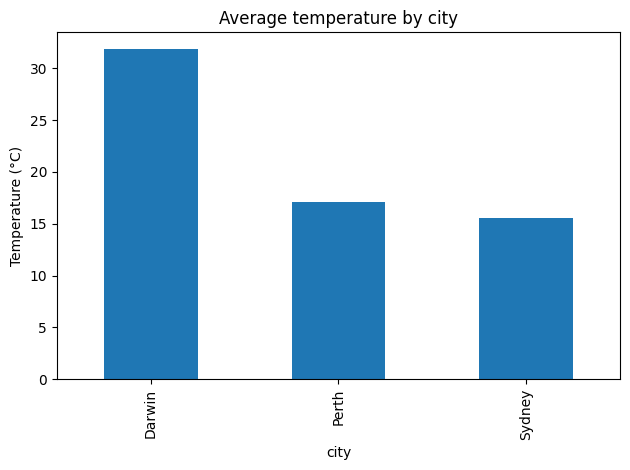

In [11]:
avg_temp = df.groupby("city")["temperature"].mean()

avg_temp.plot(kind="bar", title="Average temperature by city")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

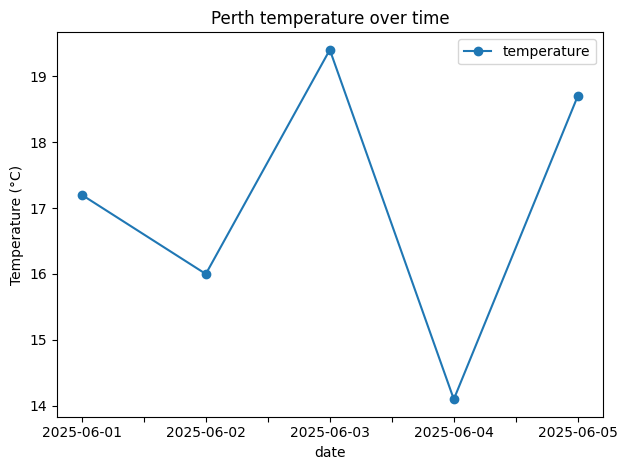

In [12]:
perth = df[df["city"] == "Perth"]

perth.plot(x="date", y="temperature", kind="line", marker="o",
           title="Perth temperature over time")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

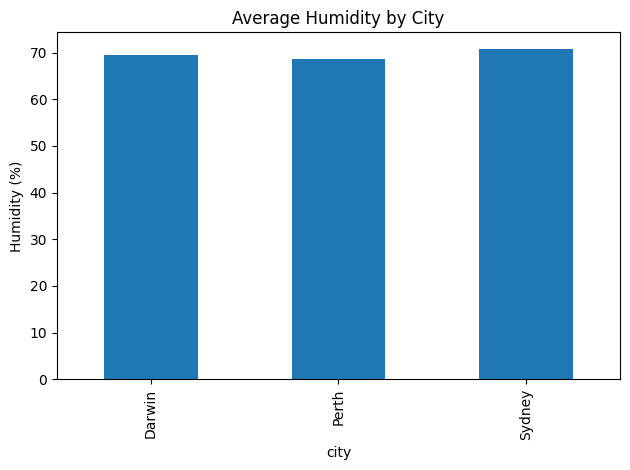

In [13]:
#Average Humidity by City
avg_humidity = df.groupby("city")["humidity"].mean()

avg_humidity.plot(kind="bar", title="Average Humidity by City")
plt.ylabel("Humidity (%)")
plt.tight_layout()
plt.show()

### Darwin and Perth Temperatures Over Time

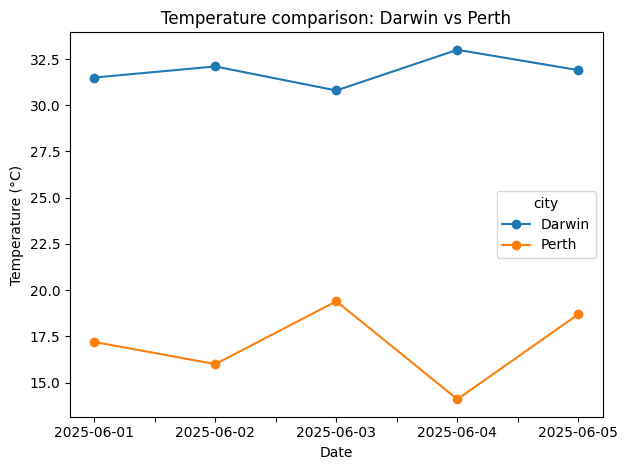

In [14]:
#Darwin and Perth Temperatures Over Time
darwin_perth = df[df["city"].isin(["Darwin", "Perth"])]

pivot_df = darwin_perth.pivot(index="date", columns="city", values="temperature")

pivot_df.plot(kind="line", marker="o", title="Temperature comparison: Darwin vs Perth")
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [15]:
# Only if in Jupyter/colab, otherwise just run the pip command in the terminal
!pip install pandasql

from pandasql import sqldf

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26867 sha256=da032b911765008c539dfcdb2873a8fadf3eecc9718f8d38b23104f6dad817eb
  Stored in directory: /root/.cache/pip/wheels/b4/d0/8c/a6b366870bf041849cd96e03b71641e082f8d6456269b603b7
Successfully built pandasql


In [16]:
perth = sqldf("SELECT * FROM df WHERE city = 'Perth'", globals())
print(perth)

warm_perth = sqldf("SELECT * FROM df WHERE city = 'Perth' AND temperature > 18", globals())
print(warm_perth)

         date   city  temperature  humidity conditions
0  2025-06-01  Perth         17.2        62      Sunny
1  2025-06-02  Perth         16.0        80       Rain
2  2025-06-03  Perth         19.4        55      Sunny
3  2025-06-04  Perth         14.1        88       Rain
4  2025-06-05  Perth         18.7        58     Cloudy
         date   city  temperature  humidity conditions
0  2025-06-03  Perth         19.4        55      Sunny
1  2025-06-05  Perth         18.7        58     Cloudy


In [17]:
summary = sqldf("""
    SELECT city,
           AVG(temperature) AS avg_temp,
           MAX(temperature) AS max_temp,
           MIN(temperature) AS min_temp,
           COUNT(*)         AS n
    FROM df
    GROUP BY city
""", globals())
print(summary)

     city  avg_temp  max_temp  min_temp  n
0  Darwin     31.86      33.0      30.8  5
1   Perth     17.08      19.4      14.1  5
2  Sydney     15.60      17.2      13.5  5
